In [ ]:
import pandas as pd
raw_csv = pd.read_csv("/media/Dataset_10191.csv")

raw_csv

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,No,No,No
1,ham,Yay can't wait to party together!,No,No,No
2,ham,At what time are you coming.,No,No,No
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",No,No,Yes
4,ham,Yo you around? A friend of mine's lookin to pi...,No,No,No
...,...,...,...,...,...
10186,spam,mobile club: choose any of the top quality ite...,No,No,No
10187,spam,"thanks for your ringtone order, reference numb...",No,No,Yes
10188,spam,u can win £100 of music gift vouchers every we...,No,No,No
10189,spam,convey the official england poly ringtone or c...,No,No,No




> The idea is to create the embedding for each row, and then concat with [URL?,EMAIL?,PHONE?] in orrde to have a 1024+3 embedding that is later fed into MLP for classification



First, preprocess the dataset

In [ ]:
from distutils.util import strtobool
counter = 0; idx_list = []
for row in raw_csv.itertuples():
  lab = row.LABEL
  txt = row.TEXT
  url = row.URL
  email = row.EMAIL
  phone = row.PHONE
  if (str(url) not in {"Yes", "No"}) or (str(email) not in {"Yes", "No"}) or (str(phone) not in {"Yes", "No"}):
    print(row)
    counter = counter +1
    idx_list.append(row.Index)
  elif len(txt) < 10:
      print(row)
      counter = counter +1
      idx_list.append(row.Index)
  else:
    raw_csv.iloc[row.Index, 2] = float(strtobool(raw_csv.iloc[row.Index, 2]))
    raw_csv.iloc[row.Index, 3] = float(strtobool(raw_csv.iloc[row.Index, 3]))
    raw_csv.iloc[row.Index, 4] = float(strtobool(raw_csv.iloc[row.Index, 4]))

raw_csv



Pandas(Index=180, LABEL='ham', TEXT='U 2.', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=312, LABEL='ham', TEXT=':)', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=578, LABEL='ham', TEXT='Yes fine', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=772, LABEL='ham', TEXT='Ok.', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=879, LABEL='ham', TEXT='Thanx...', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=1060, LABEL='ham', TEXT='Ok can...', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=1479, LABEL='ham', TEXT='Ok lor...', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=1522, LABEL='ham', TEXT='Okie', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=1769, LABEL='ham', TEXT='Ok. Fine�', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=2397, LABEL='ham', TEXT='Yup ok...', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=2740, LABEL='ham', TEXT='How come?', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=3101, LABEL='ham', TEXT='Oh ok..', URL='No', EMAIL='No', PHONE='No')
Pandas(Index=3392, LABEL

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,0.0,0.0,0.0
1,ham,Yay can't wait to party together!,0.0,0.0,0.0
2,ham,At what time are you coming.,0.0,0.0,0.0
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",0.0,0.0,1.0
4,ham,Yo you around? A friend of mine's lookin to pi...,0.0,0.0,0.0
...,...,...,...,...,...
10186,spam,mobile club: choose any of the top quality ite...,0.0,0.0,0.0
10187,spam,"thanks for your ringtone order, reference numb...",0.0,0.0,1.0
10188,spam,u can win £100 of music gift vouchers every we...,0.0,0.0,0.0
10189,spam,convey the official england poly ringtone or c...,0.0,0.0,0.0


In [ ]:
print(counter)
print(len(idx_list))

18
18


In [ ]:
main_df = raw_csv.drop(raw_csv.index[idx_list])
main_df.reset_index(inplace=True)
main_df.drop("index", axis = 1, inplace = True)
main_df

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,0.0,0.0,0.0
1,ham,Yay can't wait to party together!,0.0,0.0,0.0
2,ham,At what time are you coming.,0.0,0.0,0.0
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",0.0,0.0,1.0
4,ham,Yo you around? A friend of mine's lookin to pi...,0.0,0.0,0.0
...,...,...,...,...,...
10168,spam,mobile club: choose any of the top quality ite...,0.0,0.0,0.0
10169,spam,"thanks for your ringtone order, reference numb...",0.0,0.0,1.0
10170,spam,u can win £100 of music gift vouchers every we...,0.0,0.0,0.0
10171,spam,convey the official england poly ringtone or c...,0.0,0.0,0.0


Length distribution

In [ ]:
import numpy as np

lengths = main_df['TEXT'].apply(lambda x: len(x))

print(f"p50: {np.percentile(lengths, 50)}")
print(f"p90: {np.percentile(lengths, 90)}")
print(f"p95: {np.percentile(lengths, 95)}")
print(f"p99: {np.percentile(lengths, 99)}")
print(f"max: {lengths.max()}")

p50: 132.0
p90: 161.0
p95: 168.0
p99: 261.0
max: 790


In [ ]:
#according to the results, only text whose length is below 170 is taken
discard = []
for row in main_df.itertuples():
  if len(row.TEXT) > 169:
    discard.append(row.Index)

distributed_df = main_df.drop(main_df.index[discard])
distributed_df.reset_index(inplace=True)
distributed_df.drop("index", axis = 1, inplace = True)
distributed_df


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,0.0,0.0,0.0
1,ham,Yay can't wait to party together!,0.0,0.0,0.0
2,ham,At what time are you coming.,0.0,0.0,0.0
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",0.0,0.0,1.0
4,ham,Yo you around? A friend of mine's lookin to pi...,0.0,0.0,0.0
...,...,...,...,...,...
9683,spam,pdate_now - double mins and 1000 txts on orang...,0.0,0.0,1.0
9684,spam,mobile club: choose any of the top quality ite...,0.0,0.0,0.0
9685,spam,u can win £100 of music gift vouchers every we...,0.0,0.0,0.0
9686,spam,convey the official england poly ringtone or c...,0.0,0.0,0.0


(array([  6.,  16.,  13.,  18.,  11.,  26.,  27.,  60., 138.,  65., 111.,
        117.,  69., 122.,  86., 103., 111.,  65., 112.,  51., 111.,  59.,
         96., 104.,  58.,  94.,  45.,  81.,  59.,  24.,  62.,  24.,  65.,
         61.,  46.,  70.,  38.,  72.,  79.,  53.,  67.,  48.,  68.,  23.,
         54.,  70.,  34.,  40.,  19.,  53.,  25.,  22.,  48.,  47.,  91.,
         83.,  28.,  80.,  34.,  51.,  68.,  80.,  75.,  56.,  70.,  88.,
        109.,  98.,  30., 130.,  85., 104., 122.,  58., 139.,  62., 171.,
        133.,  72., 170.,  95., 148., 124., 217., 245., 130., 284., 189.,
        278., 376., 159., 364., 183., 457., 405., 126., 170.,  74.,  71.,
         60.]),
 array([ 10.  ,  11.59,  13.18,  14.77,  16.36,  17.95,  19.54,  21.13,
         22.72,  24.31,  25.9 ,  27.49,  29.08,  30.67,  32.26,  33.85,
         35.44,  37.03,  38.62,  40.21,  41.8 ,  43.39,  44.98,  46.57,
         48.16,  49.75,  51.34,  52.93,  54.52,  56.11,  57.7 ,  59.29,
         60.88,  62.47,  64.06

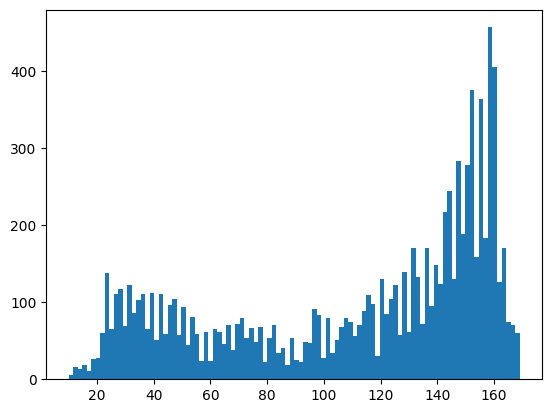

In [ ]:
import matplotlib.pyplot as plt
length = []
for row in distributed_df.itertuples():
  length.append(len(row.TEXT))

plt.hist(length, bins = 100)

Balancing

In [ ]:
for i in distributed_df["LABEL"].value_counts():
  print(i/sum(distributed_df["LABEL"].value_counts()))

# (no need balancing)
distributed_df.to_parquet("/media/preprocessed_df.parquet", engine = "pyarrow")

0.3384599504541701
0.33660198183319573
0.32493806771263417


Split dataset for train/test/val

In [ ]:
df = distributed_df[["LABEL","TEXT"]]
df.reset_index(inplace=True)
df = df[[col for col in df.columns if col != 'LABEL'] + ['LABEL']]
df.columns = ["id", "prompt", "labels"]
def int_label(x):
  if x == "ham":
    return 0
  if x == "spam":
    return 1
  if x == "smishing":
    return 2

df["labels"] = df["labels"].apply(int_label)
df

,id,prompt,labels
0,0,Hi! You just spoke to DEEPAK. We'd like to kno...,0
1,1,Yay can't wait to party together!,0
2,2,At what time are you coming.,0
3,3,"Dear customer your PAY2TMKYC has been expired,...",2
4,4,Yo you around? A friend of mine's lookin to pi...,0
...,...,...,...
9683,9683,pdate_now - double mins and 1000 txts on orang...,1
9684,9684,mobile club: choose any of the top quality ite...,1
9685,9685,u can win £100 of music gift vouchers every we...,1
9686,9686,convey the official england poly ringtone or c...,1


In [ ]:
import numpy as np
from datasets import Dataset, DatasetDict

# Convierte a un Dataset de Hugging Face
full_dataset = Dataset.from_pandas(df, preserve_index=False)
# Convierte la columna 'labels' de Value a ClassLabel
full_dataset = full_dataset.class_encode_column("labels")

# Split train/test (mismo split estratificado que comentamos antes)
test_split_dataset = full_dataset.train_test_split(
    test_size=0.15,       # ajusta para llegar a tus proporciones (4921/20227 ≈ 0.243)
    seed=33,
    stratify_by_column="labels"  # mantiene el balance de clases en ambos splits
)
trainval_split_dataset = test_split_dataset["train"].train_test_split(
    test_size=0.2,       # ajusta para llegar a tus proporciones (4921/20227 ≈ 0.243)
    seed=33,
    stratify_by_column="labels"  # mantiene el balance de clases en ambos splits
)

dataset_dict = DatasetDict({
    "train": trainval_split_dataset["train"],
    "val": trainval_split_dataset["test"],
    "test": test_split_dataset["test"]
})

print(dataset_dict)

Stringifying the column:   0%|          | 0/9688 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/9688 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'prompt', 'labels'],
        num_rows: 6587
    })
    val: Dataset({
        features: ['id', 'prompt', 'labels'],
        num_rows: 1647
    })
    test: Dataset({
        features: ['id', 'prompt', 'labels'],
        num_rows: 1454
    })
})


**Loading modernBERT Model**

loading tokenizer

In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding

model_id = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Verifica el max_length real antes de fijarlo a ciegas
# (usa los percentiles que calculamos antes, no un número arbitrario)
tokenizer.model_max_length = 170

def tokenize(batch):
    return tokenizer(
        batch['prompt'],
        truncation=True,
        max_length=tokenizer.model_max_length,
        # sin padding aquí — se hace dinámicamente en el collator
    )

tokenized_dataset = dataset_dict.map(
    tokenize,
    batched=True,
    remove_columns=["prompt"]
)

print(tokenized_dataset["train"].features.keys())
# dict_keys(['id', 'labels', 'input_ids', 'attention_mask'])

# Data collator para padding dinámico por batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Map:   0%|          | 0/6587 [00:00<?, ? examples/s]

Map:   0%|          | 0/1647 [00:00<?, ? examples/s]

Map:   0%|          | 0/1454 [00:00<?, ? examples/s]

dict_keys(['id', 'labels', 'input_ids', 'attention_mask'])


In [ ]:
tokenized_dataset["train"][0]

{'id': 571,
 'labels': 0,
 'input_ids': [50281, 37161, 247, 4564, 3038, 27164, 50282],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [ ]:
df.iloc[571,:]

,571
id,571
prompt,Probably a couple hours tops
labels,0


In [ ]:
example = tokenized_dataset["train"][0]
decoded_text = tokenizer.decode(example["input_ids"])
print(decoded_text)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[CLS]Probably a couple hours tops[SEP]


Loading model itself

In [ ]:
from transformers import AutoModelForSequenceClassification

# Model id to load the tokenizer
model_id = "answerdotai/ModernBERT-base"

label2id = {"ham":0, "spam":1, "smishing":2}
id2label = {0:"ham", 1:"spam", 2:"smishing"}

num_labels = len(id2label.keys())

# Download the model from huggingface.co/models
model = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=num_labels, label2id=label2id, id2label=id2label,
)



model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


fine-tunning modernBERT

In [ ]:
#####
#creating metrics
#####
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_weighted": f1_weighted,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
    }



## training
from transformers import Trainer, TrainingArguments

# Define training args
training_args = TrainingArguments(
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
		num_train_epochs=5,
    bf16=True, # bfloat16 training
    optim="adamw_torch_fused", # improved optimizer
    # logging & evaluation strategies
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True, #save the model in cache for saving it later
    metric_for_best_model="accuracy"
)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,F1 Weighted,Precision Weighted,Recall Weighted
1,0.040110,0.058211,0.984214,0.984131,0.984152,0.984289,0.984201,0.984366,0.984214
2,0.036245,0.052689,0.984821,0.984826,0.985008,0.984715,0.984832,0.984912,0.984821
3,0.025371,0.054787,0.987857,0.987849,0.987959,0.987779,0.987870,0.987924,0.987857
4,0.019336,0.041794,0.986035,0.985980,0.985956,0.986025,0.986022,0.986029,0.986035
5,0.017226,0.042985,0.986035,0.985989,0.985983,0.985995,0.986031,0.986028,0.986035


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1030, training_loss=0.02794130198585177, metrics={'train_runtime': 1021.3844, 'train_samples_per_second': 32.245, 'train_steps_per_second': 1.008, 'total_flos': 1260886646769102.0, 'train_loss': 0.02794130198585177, 'epoch': 5.0})

In [ ]:
predictions = trainer.predict(tokenized_dataset["test"])
predictions.metrics

{'test_loss': 0.06189268082380295,
 'test_accuracy': 0.9807427785419532,
 'test_f1_macro': 0.9807165158839647,
 'test_precision_macro': 0.9809140981701879,
 'test_recall_macro': 0.9806049614666758,
 'test_f1_weighted': 0.9807689604147835,
 'test_precision_weighted': 0.980881395297289,
 'test_recall_weighted': 0.9807427785419532,
 'test_runtime': 10.3664,
 'test_samples_per_second': 140.261,
 'test_steps_per_second': 8.778}

In [ ]:
### save model (without MLP for classification) and tokenizer
backbone = trainer.model.base_model
backbone.save_pretrained("/media/modernbert-finetuned-backbone")
tokenizer.save_pretrained("/media/modernbert-finetuned-backbone") #save when correctly checked on test
#also saved on huggingface

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/media/modernbert-finetuned-backbone/tokenizer_config.json',
 '/media/modernbert-finetuned-backbone/tokenizer.json')

Creating CLS embedding dataset

In [ ]:
for num in range(1,500):
  if (df.shape[0] % num) == 0:
    print(num)

1
2
4
7
8
14
28
56
173
346


In [ ]:
from transformers import AutoModel, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
backbone = AutoModel.from_pretrained("/media/modernbert-finetuned-backbone")
tokenizer = AutoTokenizer.from_pretrained("/media/modernbert-finetuned-backbone")
backbone.to(device)
backbone.eval()


def get_cls_embeddings_from_texts(texts, tokenizer, backbone, device, batch_size=56, max_length=170):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            inputs = tokenizer(
                batch_texts,
                truncation=True,
                max_length=max_length,
                padding=True,           # padding dinámico solo dentro de este batch
                return_tensors="pt"
            ).to(device)

            outputs = backbone(**inputs)
            cls_embed = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

            all_embeddings.append(cls_embed.cpu())

    return torch.cat(all_embeddings, dim=0)  # (total_samples, 768)



Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

In [ ]:
texts = df["prompt"].tolist()

cls_embeddings = get_cls_embeddings_from_texts(
    texts,
    tokenizer,
    backbone,
    device,
    batch_size=32,
    max_length=170
)
cls_embeddings

tensor([[ 1.0535, -0.5590,  1.7629,  ..., -1.1213,  1.9403, -1.7048],
        [ 1.0421, -1.0528,  1.0241,  ..., -1.0558,  1.9756, -1.0084],
        [ 1.7623, -0.6273,  1.4384,  ..., -0.7052,  2.1472, -1.7012],
        ...,
        [ 2.1571,  0.7646, -0.6637,  ...,  0.7445,  1.0390,  0.4583],
        [ 1.1681,  0.2921, -0.8375,  ...,  0.6731,  0.4612, -0.5835],
        [ 1.8202,  0.6336,  0.0946,  ..., -0.2060, -0.0142,  0.0379]])

In [ ]:
final_cls_list = []
for l in range(cls_embeddings.shape[0]):
  final_cls_list.append(cls_embeddings[l].numpy().tolist())
print(len(final_cls_list))
df["cls_embedding"] = final_cls_list
df.to_parquet("/media/embeddings_df.parquet",engine="pyarrow")
df

9688


,id,prompt,labels,cls_embedding
0,0,Hi! You just spoke to DEEPAK. We'd like to kno...,0,"[1.053519368171692, -0.5589970350265503, 1.762..."
1,1,Yay can't wait to party together!,0,"[1.042068362236023, -1.052781343460083, 1.0240..."
2,2,At what time are you coming.,0,"[1.76233971118927, -0.627250075340271, 1.43843..."
3,3,"Dear customer your PAY2TMKYC has been expired,...",2,"[-2.078895330429077, -0.6496822237968445, 0.40..."
4,4,Yo you around? A friend of mine's lookin to pi...,0,"[0.3308568298816681, 0.04425649344921112, 1.82..."
...,...,...,...,...
9683,9683,pdate_now - double mins and 1000 txts on orang...,1,"[1.9835833311080933, 0.5916808843612671, 0.172..."
9684,9684,mobile club: choose any of the top quality ite...,1,"[1.6379735469818115, 0.7550704479217529, 0.159..."
9685,9685,u can win £100 of music gift vouchers every we...,1,"[2.1570680141448975, 0.7646427750587463, -0.66..."
9686,9686,convey the official england poly ringtone or c...,1,"[1.1681472063064575, 0.2921214997768402, -0.83..."


Defining MLP

In [ ]:
# destacar que en moderBERT, cada token posee un embedding de longitud 768
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class MultiClassClassifier(nn.Module):
    def __init__(self, cls_dim = 768, proj_dim = 96, remaining_cols = 3, hidden_dim = 40):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(cls_dim, proj_dim),
                                  nn.BatchNorm1d(proj_dim),
                                  nn.ReLU())
                                #   nn.Dropout(dropout))
        # self.motif_mlp = nn.Sequential(nn.Linear(motif_dim, motif_dim),
        #                                nn.BatchNorm1d(motif_dim),
        #                                nn.ReLU(),
        #                                nn.Dropout(dropout))
        self.classifier = nn.Sequential(nn.Linear(proj_dim + remaining_cols, hidden_dim),
                                        nn.BatchNorm1d(hidden_dim),
                                        nn.ReLU(),
                                        # nn.Dropout(dropout),
                                        nn.Linear(hidden_dim, 3)) #! Multi-class logit
    def forward(self, cls_embed, cols_data):
        seq_proj = self.proj(cls_embed)
        # motif_proj = self.motif_mlp(motif_embed)
        x = torch.cat([seq_proj, cols_data], dim=1) #! Concat embeddings
        logits = self.classifier(x)
        return logits

Creating splits for training

In [ ]:
import pandas as pd
import numpy as np
import pickle as pkl
import copy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

proc_csv = pd.read_parquet("/media/preprocessed_df.parquet",engine = "pyarrow")

pairs = pd.read_parquet("/media/embeddings_df.parquet", engine="pyarrow")
org_cols = pairs.columns

#adding url, email, hone info
url = []
phone = []
email = []
for row in proc_csv.itertuples():
  url.append(row.URL)
  phone.append(row.PHONE)
  email.append(row.EMAIL)

pairs = pd.concat([pairs, pd.DataFrame(url), pd.DataFrame(email), pd.DataFrame(phone)], axis = 1)
new_cols = list(org_cols) + ["URL","EMAIL", "PHONE"]
pairs.columns = new_cols

train_df, temp_df = train_test_split(pairs, test_size = 0.15, stratify = pairs['labels'], random_state = 33)
val_df, test_df = train_test_split(temp_df, test_size = 0.2, stratify = temp_df['labels'], random_state = 33)

#! Sequence embedding scaler
scaler = StandardScaler()

train_scaled = train_df.copy()
train_embeds = np.stack(train_df['cls_embedding'].to_numpy())
train_scaled["cls_embedding"] = list(scaler.fit_transform(train_embeds))

val_scaled = val_df.copy()
val_embeds = np.stack(val_df['cls_embedding'].to_numpy())
val_scaled["cls_embedding"] = list(scaler.transform(val_embeds))

test_scaled = test_df.copy()
test_embeds = np.stack(test_df['cls_embedding'].to_numpy())
test_scaled["cls_embedding"] = list(scaler.transform(test_embeds))

with open('/media/cls_scaler.pkl', 'wb') as f:
    pkl.dump(scaler, f)



In [ ]:
test_scaled

,id,prompt,labels,cls_embedding,URL,EMAIL,PHONE
5208,5208,"500 new mobiles from 2004, must go! txt: nokia...",2,"[-1.465933346633474, -0.0322113141715243, 0.25...",0.0,0.0,1.0
3536,3536,"Me also da, i feel yesterday night wait til 2...",0,"[0.18138971944652274, -0.7914049664682911, 0.4...",0.0,0.0,0.0
636,636,"Daddy, shu shu is looking 4 u... U wan me 2 te...",0,"[0.21048010236209547, -0.28429194386762346, 1....",0.0,0.0,0.0
4379,4379,private! your 2004 account statement for 07742...,2,"[-1.0124333327776671, -0.49870736962377116, 0....",0.0,0.0,1.0
7211,7211,freemsg hey there darling it's been 3 week's n...,1,"[0.4181010621524262, 0.3200880878841279, -0.53...",0.0,0.0,0.0
...,...,...,...,...,...,...,...
1990,1990,Not yet chikku..wat abt u?,0,"[0.47960245682477376, -0.21959973640140015, 0....",0.0,0.0,0.0
3619,3619,We have identified some unusual activity on yo...,2,"[0.13907780706292677, -1.433307694410181, 0.33...",0.0,0.0,0.0
6487,6487,you have be specially choose to incur a 2000 p...,2,"[-0.6822423228235615, 0.8497847871952658, -0.0...",0.0,0.0,1.0
4400,4400,you embody grant a sipix digital camera! call ...,2,"[-0.9319604776438465, -0.3712328363532579, 0.7...",0.0,0.0,1.0


In [ ]:
class InputDataset(Dataset):
    def __init__(self, pairs_df):
        self.pairs_df = pairs_df[["prompt", "labels", "cls_embedding", "URL", "EMAIL", "PHONE"]].reset_index(drop=True)
    def __len__(self):
        return len(self.pairs_df)
    def __getitem__(self, idx):
        row = self.pairs_df.iloc[idx]
        #Seq embedding and additional info
        cls = row["cls_embedding"]
        url = row["URL"]
        email = row["EMAIL"]
        phone = row["PHONE"]
        v_concat = np.concatenate([cls, [url], [email], [phone]])

        #Label
        y = row['labels']

        return {"seq_info": torch.tensor(v_concat, dtype = torch.float32),
                "y": torch.tensor(y, dtype=torch.float32)}


#! Scaled datasets
train_dataset = InputDataset(train_scaled)
val_dataset = InputDataset(val_scaled)
test_dataset = InputDataset(test_scaled)
#! Dataloaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

Training MLP

In [ ]:
#* ... Defininf model, optimizer and loss ----
num_epochs = 40
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model_path = '/media/best_MLP_model.pt'
model = MultiClassClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)

In [ ]:
#* ... Function to evaluate model ----
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

def evaluate(model, dataloader, loss_fn, device="cpu"):
    model.eval()
    all_logits = []
    all_labels = []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            seq = batch['seq_info'].to(device)
            labels = batch['y'].to(device)
            logits = model(seq[:,:-3], seq[:,-3:])
            loss = loss_fn(logits, labels.long()) #PyTorch's CrossEntropyLoss requires the target to be Long (int64) — it expects class indices, not floats.
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())
    all_logits = torch.cat(all_logits)
    all_probs = torch.sigmoid(all_logits)  # sigmoid
    y_pred = np.argmax(all_probs.cpu().numpy(), axis=1) #predicted
    all_labels = torch.cat(all_labels)
    # Accuracy
    acc = accuracy_score(all_labels, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Macro F1
    macro_f1 = f1_score(all_labels, y_pred, average='macro')
    print(f"Macro F1: {macro_f1:.4f}")

    return {'accuracy': acc,
            'f1': macro_f1,
            'Confussion_Matrix': cm}



#* ... Training ----
metrics_history = []
best_acc = 0
for epoch in range(1, num_epochs+1):
    print("")
    print(f"Epoch = {epoch}")
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        seq = batch['seq_info'].to(device)
        labels = batch['y'].to(device)
        optimizer.zero_grad()
        logits = model(seq[:,:-3], seq[:,-3:])
        loss = loss_fn(logits, labels.long()) #PyTorch's CrossEntropyLoss requires the target to be Long (int64) — it expects class indices, not floats.
        loss.backward()
        optimizer.step()
    #evaluate for obtianing metrics
    metrics = evaluate(model, val_loader, loss_fn, device)
    acc_val = metrics["accuracy"]
    if acc_val > best_acc:
      best_acc = acc_val
      torch.save(model.state_dict(), best_model_path)
    metrics_history.append({
        "epoch": epoch,
        "accuracy": metrics["accuracy"],
        "F1_score": metrics["f1"],
        "Confussion": metrics['Confussion_Matrix']})



Accuracy: 0.9854
Confusion Matrix:
[[391   0   0]
 [  4 389   1]
 [  3   9 366]]
Macro F1: 0.9853
Accuracy: 0.9802
Confusion Matrix:
[[391   0   0]
 [  4 380  10]
 [  2   7 369]]
Macro F1: 0.9801
Accuracy: 0.9880
Confusion Matrix:
[[391   0   0]
 [  3 389   2]
 [  2   7 369]]
Macro F1: 0.9879
Accuracy: 0.9811
Confusion Matrix:
[[391   0   0]
 [  3 380  11]
 [  2   6 370]]
Macro F1: 0.9810
Accuracy: 0.9837
Confusion Matrix:
[[391   0   0]
 [  3 382   9]
 [  1   6 371]]
Macro F1: 0.9836
Accuracy: 0.9888
Confusion Matrix:
[[391   0   0]
 [  3 389   2]
 [  1   7 370]]
Macro F1: 0.9888
Accuracy: 0.9897
Confusion Matrix:
[[391   0   0]
 [  2 390   2]
 [  1   7 370]]
Macro F1: 0.9896
Accuracy: 0.9871
Confusion Matrix:
[[391   0   0]
 [  2 384   8]
 [  1   4 373]]
Macro F1: 0.9870
Accuracy: 0.9854
Confusion Matrix:
[[391   0   0]
 [  2 385   7]
 [  1   7 370]]
Macro F1: 0.9853
Accuracy: 0.9888
Confusion Matrix:
[[391   0   0]
 [  2 390   2]
 [  1   8 369]]
Macro F1: 0.9888
Accuracy: 0.9871
Con

In [ ]:
metrics_df = pd.DataFrame(metrics_history)
metrics_df.to_csv(f'/media/metrics.tsv',
                  sep = "\t", index = False)


#* ... Checking the performance on testing set ----
best_model = MultiClassClassifier(cls_dim = 768, proj_dim = 96, remaining_cols = 3, hidden_dim = 40)

best_model.load_state_dict(torch.load(best_model_path, map_location = device))
best_model.to(device)
best_model.eval()

test_metrics = evaluate(model = best_model,
                        dataloader = test_loader,
                        loss_fn = loss_fn,
                        device = device)

pd.DataFrame([test_metrics]).to_csv(f'/media/test_metrics.tsv',
                                    sep = "\t", index = False)

Accuracy: 0.9759
Confusion Matrix:
[[97  1  0]
 [ 1 95  2]
 [ 0  3 92]]
Macro F1: 0.9759


New data

In [3]:
string = "URGENT!!! CONGRATULATIONS YOU HAVE BEEN SELECTED - WINNER OF $500,000"


In [4]:
import pandas as pd
import re
from datetime import datetime

# Compile regular expression patterns
# Pattern for Email
email_pattern = re.compile(
    r"([a-z0-9!#$%&'*+/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+/=?^_`{|}~-]+)*(@|\sat\s)"
    r"(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(\.|\sdot\s))+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)",
    re.IGNORECASE
)

# Pattern for UEL
url_pattern = re.compile(
    r"http[s]?://(?:[a-zA-Z0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
)

# Pattern for Phone Number
phone_pattern = re.compile(
    r"\b\d{10,}\b"  # Match any number with 10 or more digits
)

# Detection Functions
def email_check(text):
    return 1.0 if email_pattern.search(str(text)) else 0.0

def url_check(text):
    return 1.0 if url_pattern.search(str(text)) else 0.0

def phone_check(text):
    return 1.0 if phone_pattern.search(str(text)) else 0.0


df_input = pd.DataFrame()
df_input["prompt"] = [string]
df_input["URL"] = [url_check(string)]
df_input["EMAIL"] = [email_check(string)]
df_input["PHONE"] = [phone_check(string)]

df_input

,prompt,URL,EMAIL,PHONE
0,URGENT!!! CONGRATULATIONS YOU HAVE BEEN SELECT...,0.0,0.0,0.0


Obtaining CLS embedding

In [5]:
from transformers import AutoModel, AutoTokenizer
import joblib
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
backbone = AutoModel.from_pretrained("./modernbert-finetuned-backbone")
tokenizer = AutoTokenizer.from_pretrained("./modernbert-finetuned-backbone")
backbone.to(device)
backbone.eval()
all_embeddings = []
max_length = 169
inputs = tokenizer(
                df_input["prompt"][0],
                truncation=True,
                max_length=max_length,
                padding=True,           # padding dinámico solo dentro de este batch
                return_tensors="pt"
            ).to(device)

outputs = backbone(**inputs)
cls_embed = outputs.last_hidden_state[:, 0, :]  # (1, 768)

df_input["cls_embedding"] = [cls_embed.cpu().tolist()[0]]


#scale embedding
loaded_scaler = joblib.load('./cls_scaler.pkl')
df_scaled = df_input.copy()
cls_embedding = np.stack(df_input['cls_embedding'].to_numpy())
df_scaled["cls_embedding"] = list(loaded_scaler.transform(cls_embedding))

#obtain input
v_concat = np.concatenate([torch.tensor(df_scaled["cls_embedding"]), torch.tensor(np.array(df_scaled["URL"]).reshape(-1, 1)), torch.tensor(np.array(df_scaled["EMAIL"]).reshape(-1, 1)), torch.tensor(np.array(df_scaled["PHONE"]).reshape(-1, 1))],axis=1)
print(v_concat.shape)
v_concat

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 1642.41it/s]


(1, 771)


/home/dsanchezg/anaconda3/envs/nlp_gpu/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_48745/2797026167.py:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  v_concat = np.concatenate([torch.tensor(df_scaled["cls_embedding"]), torch.tensor(np.array(df_scaled["URL"]).reshape(-1, 1)), torch.tensor(np.array(df_scaled["EMAIL"]).reshape(-1, 1)), torch.tensor(np.array(df_scaled["PHONE"]).reshape(-1, 1))],axis=1)


array([[-9.07492392e-01,  2.56632043e+00,  1.21920681e-01,
        -1.91992726e-01,  1.25087475e+00,  1.80730456e+00,
         5.73275100e-02, -2.37914916e-01,  7.67992463e-02,
         4.71658343e-01,  2.01173642e+00,  2.64681066e-01,
        -1.65991221e+00,  1.85760916e+00,  8.10987550e-01,
         1.45150321e+00, -1.10222742e+00,  1.22517820e+00,
         1.00182013e+00,  1.84157495e+00, -3.24897692e-01,
         3.04132144e-01,  1.02189506e+00,  2.28749524e-02,
        -3.90297091e-02, -3.22223629e-01, -1.58555118e+00,
         9.90108331e-01,  3.12050914e-01,  5.32467436e-01,
        -1.08487980e+00, -1.95957767e-01, -1.05405635e+00,
         3.44480046e+00, -1.47347890e+00,  1.29313189e+00,
         1.03309163e+00,  2.68664725e-01,  8.58904356e-01,
         3.41359930e-01,  1.45680245e-01, -6.90953079e-03,
         9.46168963e-01,  4.80310467e-02,  1.35779773e+00,
        -7.22443330e-01,  5.64074835e-01,  5.73764892e-01,
        -7.61321062e-01,  4.17391849e-04, -3.86081369e-0

Predict using MLP

In [6]:
# destacar que en moderBERT, cada token posee un embedding de longitud 768
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class MultiClassClassifier(nn.Module):
    def __init__(self, cls_dim = 768, proj_dim = 96, remaining_cols = 3, hidden_dim = 40):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(cls_dim, proj_dim),
                                  nn.BatchNorm1d(proj_dim),
                                  nn.ReLU())
                                #   nn.Dropout(dropout))
        # self.motif_mlp = nn.Sequential(nn.Linear(motif_dim, motif_dim),
        #                                nn.BatchNorm1d(motif_dim),
        #                                nn.ReLU(),
        #                                nn.Dropout(dropout))
        self.classifier = nn.Sequential(nn.Linear(proj_dim + remaining_cols, hidden_dim),
                                        nn.BatchNorm1d(hidden_dim),
                                        nn.ReLU(),
                                        # nn.Dropout(dropout),
                                        nn.Linear(hidden_dim, 3)) #! Multi-class logit
    def forward(self, cls_embed, cols_data):
        seq_proj = self.proj(cls_embed)
        # motif_proj = self.motif_mlp(motif_embed)
        x = torch.cat([seq_proj, cols_data], dim=1) #! Concat embeddings
        logits = self.classifier(x)
        return logits

In [7]:
id2label = {0:"ham", 1:"spam", 2:"smishing"}

best_model = MultiClassClassifier(cls_dim = 768, proj_dim = 96, remaining_cols = 3, hidden_dim = 40)

device = "cuda" if torch.cuda.is_available() else "cpu"

best_model.load_state_dict(torch.load("./dataset_metrics/best_MLP_model.pt", map_location = device))
best_model.to(device)
best_model.eval()

concat_tensor = torch.tensor(v_concat)
concat_tensor = concat_tensor.to(torch.float32)
with torch.no_grad():
    logits = best_model(concat_tensor[:,:-3].to(device), concat_tensor[:,-3:].to(device))
    all_probs = torch.sigmoid(logits)  # sigmoid
    y_pred = np.argmax(all_probs.cpu().numpy(), axis=1) #predicted
print(string)
print(y_pred)
print(id2label[y_pred[0]])

URGENT!!! CONGRATULATIONS YOU HAVE BEEN SELECTED - WINNER OF $500,000
[2]
smishing


In [13]:
cpu_prb=all_probs[0].cpu().numpy()

In [14]:
cpu_prb[0]

np.float32(0.24443766)